In [ ]:
from google.colab import files
uploaded = files.upload()

Saving archive (5).zip to archive (5).zip


In [ ]:
!pip install xgboost shap -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import io
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import OrdinalEncoder, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    ConfusionMatrixDisplay, roc_curve
)
print("✅ Libraries imported")

✅ Libraries imported


In [ ]:
import zipfile

raw = list(uploaded.values())[0]

with zipfile.ZipFile(io.BytesIO(raw)) as z:
    print("Files inside zip:", z.namelist())
    with z.open(z.namelist()[0]) as f:
        df = pd.read_csv(f, encoding="latin-1")

print("Shape:", df.shape)
print(df.head(3))
print("\nClass Distribution:")
print(df["Loan_Approval_Status"].value_counts(normalize=True).round(3))

Files inside zip: ['Loan Dataset.csv', 'ML_Final_Phase.ipynb']
Shape: (52000, 27)
   Applicant_ID  Gender  Age Marital_Status  Dependents     Education  \
0             1  Female   25        Married           2      Graduate   
1             2    Male   36        Married           2   High School   
2             3    Male   43         Single           0  Postgraduate   

  Employment_Status Occupation_Type Residential_Status City/Town  ...  \
0          Employed        Business                Own     Urban  ...   
1          Employed        Business                Own  Suburban  ...   
2     Self-Employed      Freelancer                Own     Urban  ...   

   Loan_Amount_Requested  Loan_Term  Loan_Purpose  Interest_Rate  Loan_Type  \
0                  24535        209          Home           4.27    Secured   
1                   8288         33          Home          14.78  Unsecured   
2                  10308        159       Vehicle          12.33    Secured   

   Co-Applicant

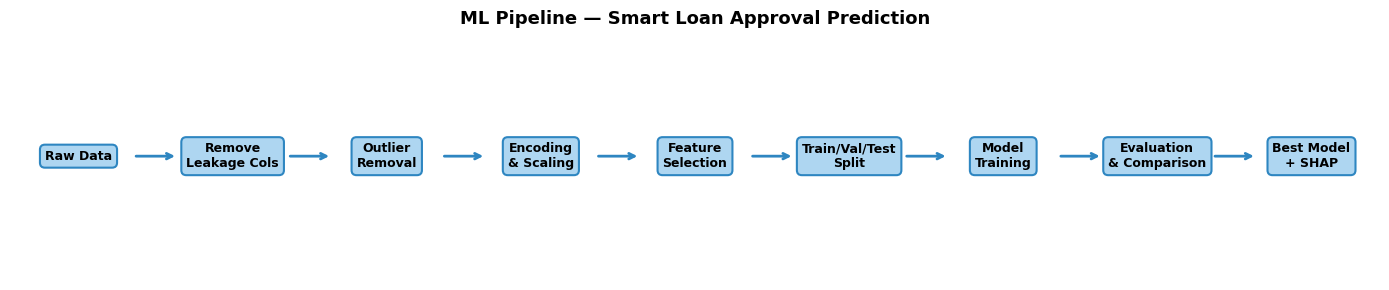

In [ ]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.axis("off")
steps = ["Raw Data", "Remove\nLeakage Cols", "Outlier\nRemoval",
         "Encoding\n& Scaling", "Feature\nSelection", "Train/Val/Test\nSplit",
         "Model\nTraining", "Evaluation\n& Comparison", "Best Model\n+ SHAP"]
x_positions = np.linspace(0.05, 0.95, len(steps))
for i, (x, step) in enumerate(zip(x_positions, steps)):
    ax.text(x, 0.5, step, ha="center", va="center", fontsize=9, fontweight="bold",
            bbox=dict(boxstyle="round,pad=0.4", facecolor="#AED6F1", edgecolor="#2E86C1", linewidth=1.5))
    if i < len(steps) - 1:
        ax.annotate("", xy=(x_positions[i+1] - 0.04, 0.5), xytext=(x + 0.04, 0.5),
                    arrowprops=dict(arrowstyle="->", color="#2E86C1", lw=2))
ax.set_title("ML Pipeline — Smart Loan Approval Prediction", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("workflow_diagram.png", dpi=150)
plt.show()

In [ ]:
# حذف Data Leakage columns
# Applicant_ID : مجرد معرّف
# Default_Risk : مشتقة من الـ target → data leakage
df.drop(columns=["Applicant_ID", "Default_Risk"], inplace=True)

TARGET = "Loan_Approval_Status"
X = df.drop(columns=[TARGET])
y = df[TARGET]

print("Label mapping (0=Rejected, 1=Approved):")
print(y.value_counts())

# Outlier Removal بطريقة IQR
def remove_outliers_iqr(X, cols):
    mask = pd.Series([True] * len(X), index=X.index)
    for col in cols:
        Q1, Q3 = X[col].quantile(0.25), X[col].quantile(0.75)
        IQR = Q3 - Q1
        mask &= (X[col] >= Q1 - 1.5*IQR) & (X[col] <= Q3 + 1.5*IQR)
    return mask

mask = remove_outliers_iqr(X, ["Annual_Income", "Loan_Amount_Requested", "Outstanding_Debt"])
X, y = X[mask], y[mask]
print(f" After outlier removal: {X.shape[0]} rows")

# تحديد نوع كل عمود
NUMERICAL = ["Age", "Dependents", "Annual_Income", "Monthly_Expenses",
             "Credit_Score", "Existing_Loans", "Total_Existing_Loan_Amount",
             "Outstanding_Debt", "Loan_Amount_Requested", "Loan_Term",
             "Interest_Rate", "Bank_Account_History", "Transaction_Frequency",
             "Loan_History"]

BINARY_CATS     = ["Gender", "Co-Applicant", "Loan_Type"]
MULTICLASS_CATS = ["Marital_Status", "Education", "Employment_Status",
                   "Occupation_Type", "Residential_Status", "City/Town", "Loan_Purpose"]

# Preprocessing Pipeline
preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("sc",  MinMaxScaler())
    ]), NUMERICAL),
    ("bin", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OrdinalEncoder())
    ]), BINARY_CATS),
    ("multi", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("enc", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), MULTICLASS_CATS),
])
print(" Preprocessor defined")

Label mapping (0=Rejected, 1=Approved):
Loan_Approval_Status
1    33366
0    18634
Name: count, dtype: int64
 After outlier removal: 51104 rows
 Preprocessor defined


In [ ]:
from sklearn.model_selection import train_test_split

# أولاً نقسم 80/20 للـ test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# بعدين نقسم الـ 80 لـ 60 train و 20 validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp
)

print(f" Train:      {X_train.shape[0]} rows (60%)")
print(f" Validation: {X_val.shape[0]} rows (20%)")
print(f" Test:       {X_test.shape[0]} rows (20%)")

# تحويل الداتا
X_train_proc = preprocessor.fit_transform(X_train, y_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

ohe_features      = preprocessor.named_transformers_["multi"].named_steps["enc"].get_feature_names_out(MULTICLASS_CATS).tolist()
all_feature_names = NUMERICAL + BINARY_CATS + ohe_features
print(f" Total features after encoding: {len(all_feature_names)}")

 Train:      30662 rows (60%)
 Validation: 10221 rows (20%)
 Test:       10221 rows (20%)
 Total features after encoding: 40


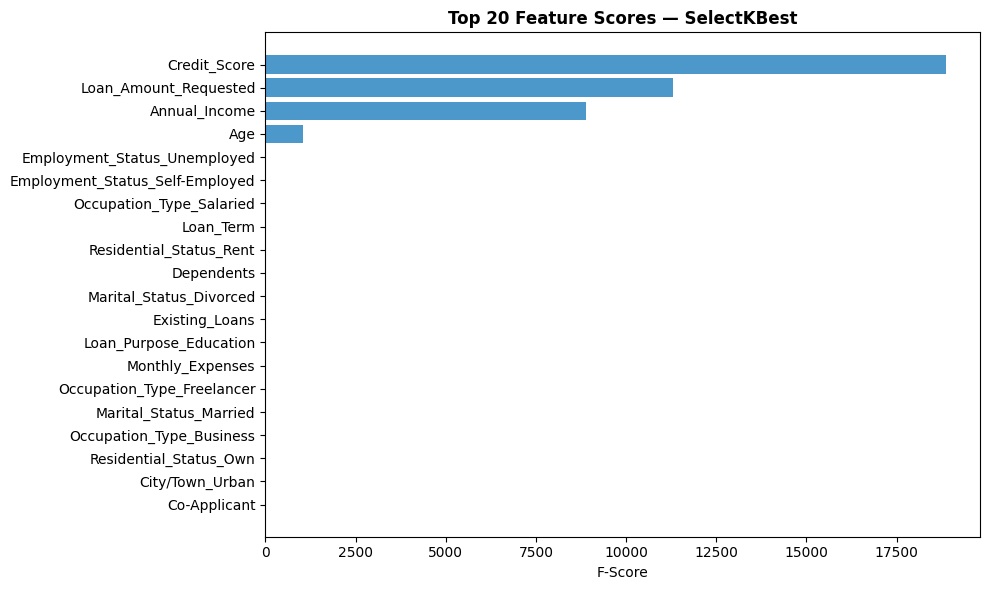

 Selected 15 features out of 40


In [ ]:
K = 15
selector   = SelectKBest(f_classif, k=K)
X_train_fs = selector.fit_transform(X_train_proc, y_train)
X_test_fs  = selector.transform(X_test_proc)

score_df = pd.DataFrame({"Feature": all_feature_names, "Score": selector.scores_})
score_df = score_df.sort_values("Score", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(score_df["Feature"][::-1], score_df["Score"][::-1], color="#2E86C1", alpha=0.85)
plt.xlabel("F-Score")
plt.title("Top 20 Feature Scores — SelectKBest", fontweight="bold")
plt.tight_layout()
plt.savefig("feature_scores.png", dpi=150)
plt.show()
print(f" Selected {K} features out of {X_train_proc.shape[1]}")


  Logistic Regression
  [Without FS] Val F1: 0.8867 | Test F1: 0.8903 | CV: 0.8865 ± 0.0020
  [With FS]    Val F1: 0.8865 | Test F1: 0.8902 | CV: 0.8865 ± 0.0020

  Decision Tree
  [Without FS] Val F1: 0.8829 | Test F1: 0.8859 | CV: 0.8795 ± 0.0054
  [With FS]    Val F1: 0.8823 | Test F1: 0.8848 | CV: 0.8793 ± 0.0049

  Random Forest
  [Without FS] Val F1: 0.8872 | Test F1: 0.8904 | CV: 0.8870 ± 0.0021
  [With FS]    Val F1: 0.8872 | Test F1: 0.8904 | CV: 0.8870 ± 0.0021

  XGBoost
  [Without FS] Val F1: 0.8841 | Test F1: 0.8881 | CV: 0.8831 ± 0.0026
  [With FS]    Val F1: 0.8850 | Test F1: 0.8875 | CV: 0.8840 ± 0.0022

  AdaBoost
  [Without FS] Val F1: 0.8872 | Test F1: 0.8904 | CV: 0.8870 ± 0.0021
  [With FS]    Val F1: 0.8872 | Test F1: 0.8904 | CV: 0.8870 ± 0.0021


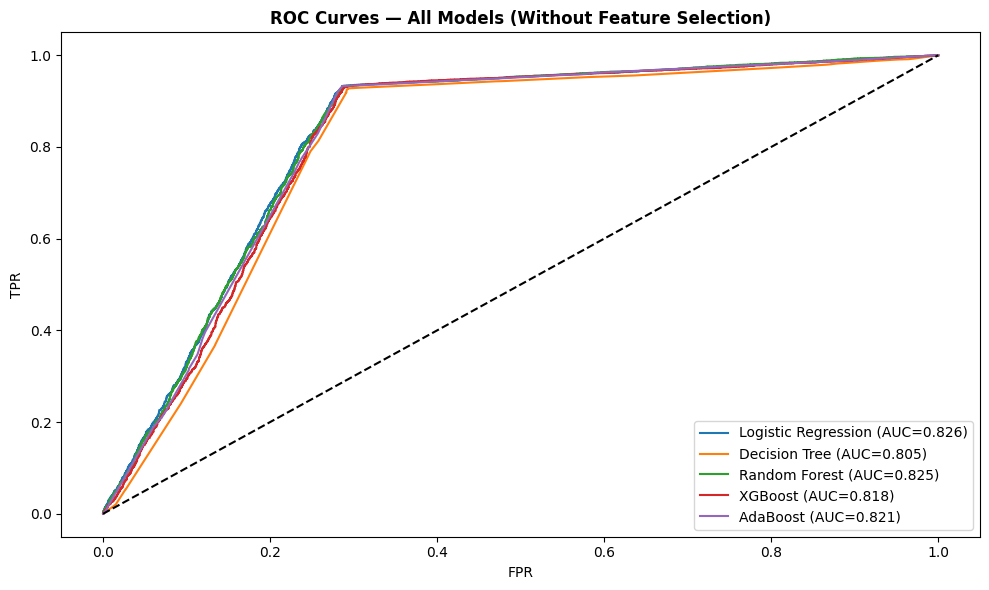

In [ ]:
# FIX 1: RandomForest — max_depth و min_samples_leaf لتجنب Overfitting
# FIX 2: AdaBoost — بدون algorithm parameter (محذوف في sklearn >= 1.6)
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree":       DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest":       RandomForestClassifier(
                               n_estimators=100,
                               max_depth=15,        # يمنع overfitting
                               min_samples_leaf=5,  # يمنع overfitting
                               random_state=42,
                               class_weight="balanced"
                           ),
    "XGBoost":             XGBClassifier(n_estimators=100, random_state=42,
                               eval_metric="logloss", verbosity=0),
    "AdaBoost":            AdaBoostClassifier(n_estimators=100, random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results_all, results_fs = [], []
fig_roc, ax_roc = plt.subplots(figsize=(10, 6))

for name, model in MODELS.items():
    print(f"\n{'='*50}\n  {name}\n{'='*50}")

    # ===== بدون Feature Selection =====
    model.fit(X_train_proc, y_train)
    y_val_pred    = model.predict(X_val_proc)
    val_f1        = f1_score(y_val, y_val_pred)
    y_pred        = model.predict(X_test_proc)
    y_proba_no_fs = model.predict_proba(X_test_proc)[:, 1]  # FIX 3: اسم واضح
    cv_scores     = cross_val_score(model, X_train_proc, y_train, cv=cv, scoring="f1")

    results_all.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "Precision": round(precision_score(y_test, y_pred), 4),
        "Recall":    round(recall_score(y_test, y_pred), 4),
        "F1-Score":  round(f1_score(y_test, y_pred), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_proba_no_fs), 4),
        "Val F1":    round(val_f1, 4),
        "CV F1":     f"{cv_scores.mean():.4f} ± {cv_scores.std():.4f}",
    })
    print(f"  [Without FS] Val F1: {val_f1:.4f} | Test F1: {f1_score(y_test,y_pred):.4f} | CV: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

    # ===== مع Feature Selection =====
    model.fit(X_train_fs, y_train)
    X_val_fs_curr = selector.transform(X_val_proc)
    y_val_pred_fs = model.predict(X_val_fs_curr)
    val_f1_fs     = f1_score(y_val, y_val_pred_fs)
    y_pred_fs     = model.predict(X_test_fs)
    y_proba_fs    = model.predict_proba(X_test_fs)[:, 1]
    cv_scores_fs  = cross_val_score(model, X_train_fs, y_train, cv=cv, scoring="f1")

    results_fs.append({
        "Model":     name,
        "Accuracy":  round(accuracy_score(y_test, y_pred_fs), 4),
        "Precision": round(precision_score(y_test, y_pred_fs), 4),
        "Recall":    round(recall_score(y_test, y_pred_fs), 4),
        "F1-Score":  round(f1_score(y_test, y_pred_fs), 4),
        "ROC-AUC":   round(roc_auc_score(y_test, y_proba_fs), 4),
        "Val F1":    round(val_f1_fs, 4),
        "CV F1":     f"{cv_scores_fs.mean():.4f} ± {cv_scores_fs.std():.4f}",
    })
    print(f"  [With FS]    Val F1: {val_f1_fs:.4f} | Test F1: {f1_score(y_test,y_pred_fs):.4f} | CV: {cv_scores_fs.mean():.4f} ± {cv_scores_fs.std():.4f}")

    # FIX 4: ROC من WITHOUT FS — y_proba_no_fs محفوظة صح
    fpr, tpr, _ = roc_curve(y_test, y_proba_no_fs)
    ax_roc.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba_no_fs):.3f})")

ax_roc.plot([0,1],[0,1],"k--")
ax_roc.set_xlabel("FPR"); ax_roc.set_ylabel("TPR")
ax_roc.set_title("ROC Curves — All Models (Without Feature Selection)", fontweight="bold")
ax_roc.legend(loc="lower right")
plt.tight_layout(); plt.savefig("roc_curves.png", dpi=150); plt.show()

In [ ]:
print("  Results WITHOUT Feature Selection:")
print(pd.DataFrame(results_all).to_string(index=False))

print("\n  Results WITH Feature Selection (K=15):")
print(pd.DataFrame(results_fs).to_string(index=False))

  Results WITHOUT Feature Selection:
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Val F1           CV F1
Logistic Regression    0.8532     0.8512  0.9331    0.8903   0.8261  0.8867 0.8865 ± 0.0020
      Decision Tree    0.8476     0.8476  0.9279    0.8859   0.8053  0.8829 0.8795 ± 0.0054
      Random Forest    0.8534     0.8516  0.9328    0.8904   0.8249  0.8872 0.8870 ± 0.0021
            XGBoost    0.8505     0.8498  0.9301    0.8881   0.8183  0.8841 0.8831 ± 0.0026
           AdaBoost    0.8534     0.8516  0.9328    0.8904   0.8212  0.8872 0.8870 ± 0.0021

  Results WITH Feature Selection (K=15):
              Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC  Val F1           CV F1
Logistic Regression    0.8530     0.8508  0.9333    0.8902   0.8268  0.8865 0.8865 ± 0.0020
      Decision Tree    0.8462     0.8476  0.9253    0.8848   0.8071  0.8823 0.8793 ± 0.0049
      Random Forest    0.8534     0.8516  0.9328    0.8904   0.8241  0.8872 0.8870 ± 0.0021
 

Fitting 5 folds for each of 15 candidates, totalling 75 fits
 Best Params: {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 10, 'max_features': 'log2', 'max_depth': 20}
 Train F1: 0.8870 | Test F1: 0.8904 | Gap: -0.0034
 ROC-AUC: 0.8278
              precision    recall  f1-score   support

    Rejected       0.86      0.71      0.78      3700
    Approved       0.85      0.93      0.89      6521

    accuracy                           0.85     10221
   macro avg       0.85      0.82      0.83     10221
weighted avg       0.85      0.85      0.85     10221



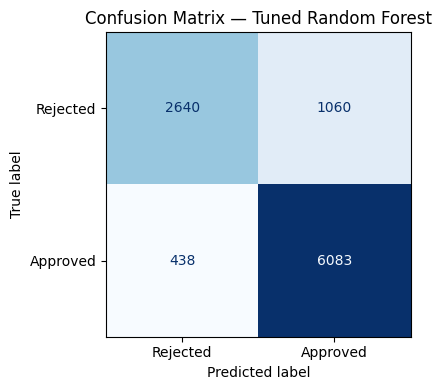

In [ ]:
rf_params = {
    "n_estimators":      [100, 200, 300],
    "max_depth":         [10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 5, 10],   # أضفنا هذا
    "max_features":      ["sqrt", "log2"],
}

rf     = RandomForestClassifier(random_state=42, class_weight="balanced")
search = RandomizedSearchCV(rf, rf_params, n_iter=15, cv=5, scoring="f1",
                             random_state=42, n_jobs=-1, verbose=1)
search.fit(X_train_proc, y_train)
best_rf = search.best_estimator_

y_pred_best  = best_rf.predict(X_test_proc)
y_proba_best = best_rf.predict_proba(X_test_proc)[:, 1]

train_f1_best = f1_score(y_train, best_rf.predict(X_train_proc))
test_f1_best  = f1_score(y_test, y_pred_best)

print(f" Best Params: {search.best_params_}")
print(f" Train F1: {train_f1_best:.4f} | Test F1: {test_f1_best:.4f} | Gap: {train_f1_best - test_f1_best:.4f}")
print(f" ROC-AUC: {roc_auc_score(y_test, y_proba_best):.4f}")
print(classification_report(y_test, y_pred_best, target_names=["Rejected","Approved"]))

fig_cm, ax_cm = plt.subplots(figsize=(5,4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_best,
    display_labels=["Rejected","Approved"],
    ax=ax_cm, colorbar=False, cmap="Blues"
)
ax_cm.set_title("Confusion Matrix — Tuned Random Forest")
plt.tight_layout(); plt.savefig("confusion_matrix.png", dpi=150); plt.show()

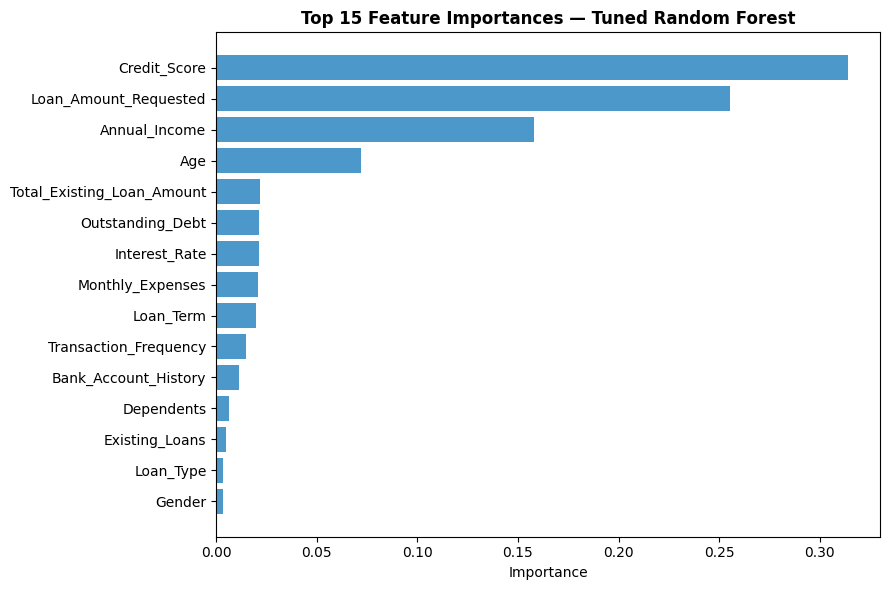

In [ ]:
feat_imp_df = pd.DataFrame({
    "Feature":    all_feature_names,
    "Importance": best_rf.feature_importances_
}).sort_values("Importance", ascending=False).head(15)

plt.figure(figsize=(9,6))
plt.barh(feat_imp_df["Feature"][::-1], feat_imp_df["Importance"][::-1], color="#2E86C1", alpha=0.85)
plt.xlabel("Importance")
plt.title("Top 15 Feature Importances — Tuned Random Forest", fontweight="bold")
plt.tight_layout(); plt.savefig("feature_importance.png", dpi=150); plt.show()

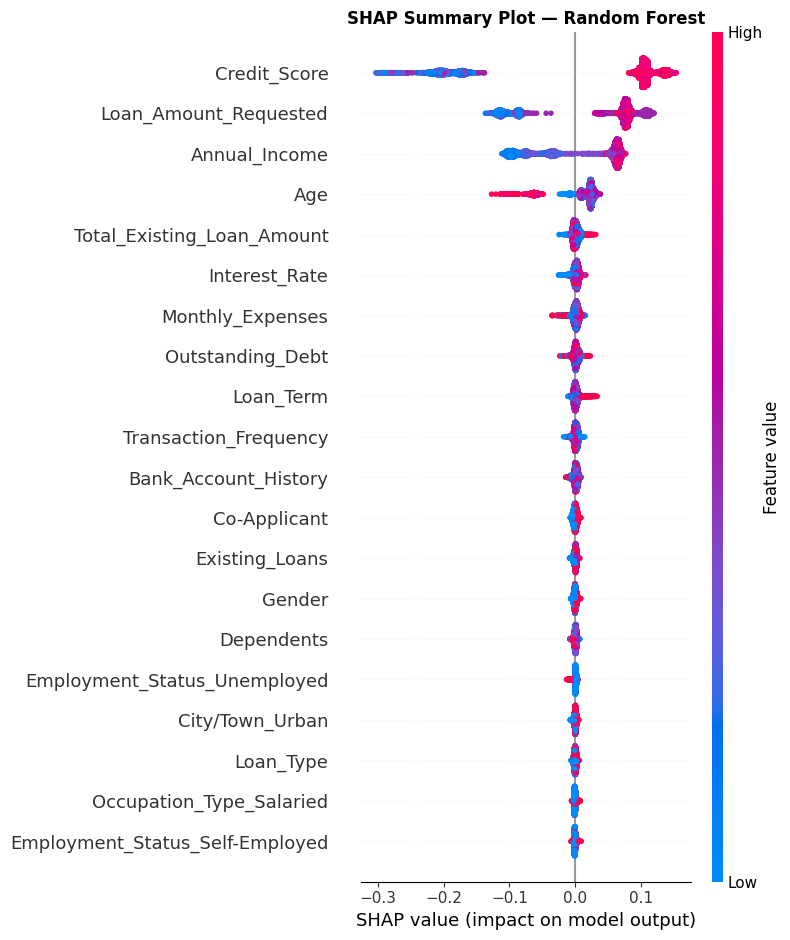

In [ ]:
explainer   = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_proc)

shap.summary_plot(shap_values[:,:,1], X_test_proc,
                  feature_names=all_feature_names, show=False)
plt.title("SHAP Summary Plot — Random Forest", fontweight="bold")
plt.tight_layout(); plt.savefig("shap_summary.png", dpi=150); plt.show()

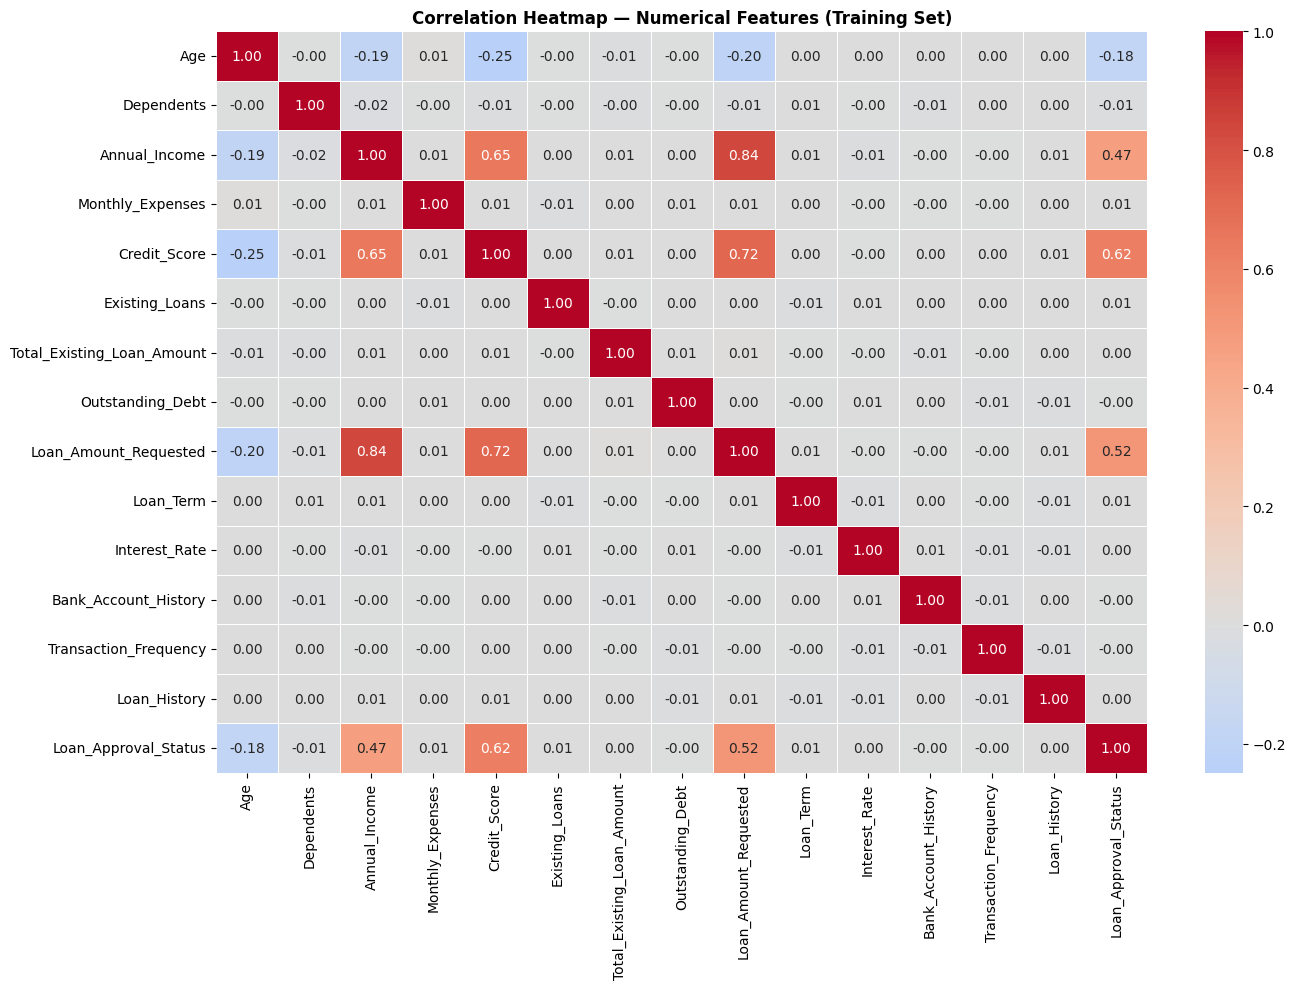

In [ ]:
# على X_train فقط (أصح من الداتا الكاملة)
df_train_corr = X_train[NUMERICAL].copy()
df_train_corr[TARGET] = y_train.values

plt.figure(figsize=(14, 10))
sns.heatmap(df_train_corr.corr(), annot=True, fmt=".2f",
            cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap — Numerical Features (Training Set)", fontweight="bold")
plt.tight_layout()
plt.savefig("correlation_heatmap.png", dpi=150)
plt.show()